In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import null_space
import cvxpy as cp
from scipy.optimize import linprog
import copy
from physiology_utilities import computeFlows, dictToVec, vecToDict, dictToGraph, graphToDict, implementGraphStruct, dictOfFxns
from dynamics_fxns import odemasterfxn

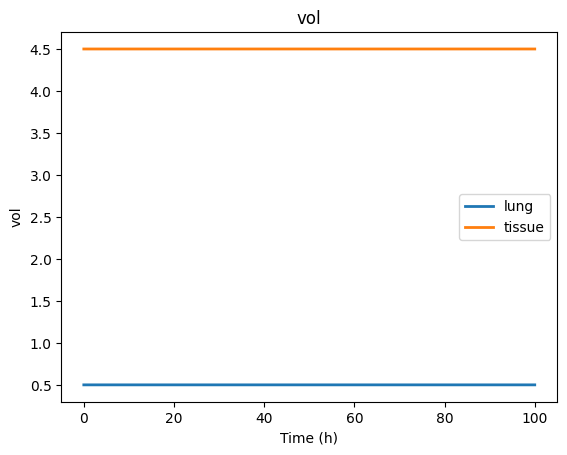

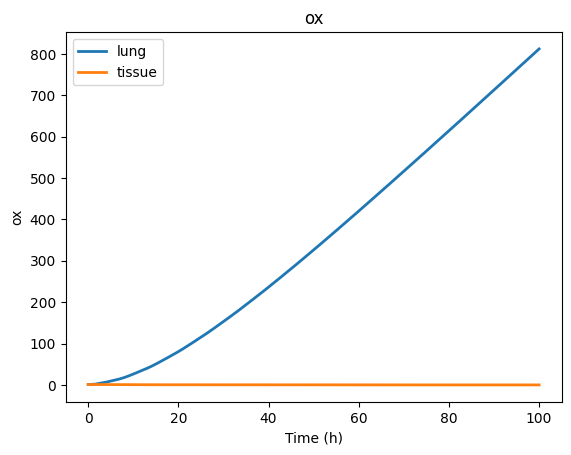

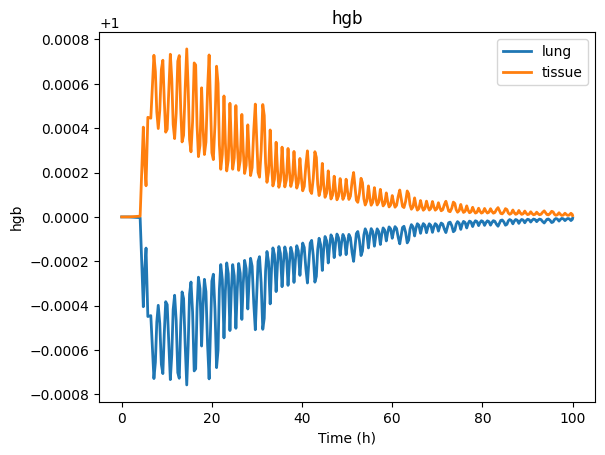

In [6]:
### Initial states and constants
speciesList = ['vol','hgb','ox']
compartmentList = ['lung','tissue']

# Initialize state for each species
stateDict = vecToDict(0,speciesList,compartmentList)

# Homeostatic distribution of species (flows will be back-computed from this)
stateDict['vol']['tissue'] = 4.5
stateDict['vol']['lung'] = 0.5

# Starting to build a special library of binding functions...
# First we need a function that defines 'is carried by'
# TODO: silly to threard through a different argument for every binding relationship, but let's do that for now
carrierDict = {}
carrierDict['vol'] = []
carrierDict['hgb'] = 'vol'
carrierDict['ox'] = 'hgb'

stateDict['ox']['tissue'] = 1.0
stateDict['ox']['lung'] = 1.0

stateDict['hgb']['tissue'] = 1.0
stateDict['hgb']['lung'] = 1.0

# Build a vector of the homeostatic levels for numerical computations 
V = []
for cpt in compartmentList: 
    V.append(stateDict[speciesList[0]][cpt])
V = np.array(V)

# Initialize data structure over which we will compute rates
structDef_In = {}; structDef_Out = {}
structDef_Out['tissue']=['lung']
structDef_Out['lung']=['tissue']
flowK = graphToDict(0,compartmentList)
flowK = implementGraphStruct(flowK,compartmentList,structDef_Out,structDef_In)

# Compute the rates from steay-state data (up to fluxes)
# NOTE: fluxes ARE important for perturbation response! 
# TODO: thread through functionalization k(t,x) everywhere
flowK = computeFlows(dictToGraph(flowK,compartmentList),V)
flowK = graphToDict(flowK,compartmentList)
initialStateVec = dictToVec(stateDict,speciesList,compartmentList)

# Time span (h)
t_start = 0.0
t_end = 100.0
t_span = (t_start, t_end)

# initialized growth rates
growth = vecToDict(0,speciesList,compartmentList)

# initialize external inflows/outflows as functions
externalK = dictOfFxns(vecToDict(0,speciesList,compartmentList))
externalW = dictOfFxns(vecToDict(0,speciesList,compartmentList))
# Tissue load
externalK['ox']['tissue'] = lambda t, x: -.05 * (np.sin(t)+1)
# Feedback relationship implemented in lung (high gain right now, while I think through details.)
externalW['ox']['lung'] = lambda t, x: 10 * (1.0-x['tissue'])

### ODE solver call (Runge-Kutta)
solution = solve_ivp(odemasterfxn,[t_start,t_end],initialStateVec,method='RK45',args = (speciesList,compartmentList,flowK,externalK,externalW,growth,carrierDict))

### Plotting
tsPlot = vecToDict(solution.y,speciesList,compartmentList)
plotSpeciesList = ['vol','ox','hgb']
for species in plotSpeciesList:
    plt.figure()
    for key in tsPlot[species].keys():
        plt.plot(solution.t, tsPlot[species][key], linewidth=2,label=key)
    plt.ylabel(species)
    plt.xlabel('Time (h)')
    plt.title(species)
    plt.legend()